# Tuning Score vs Spatial Shift — Grid, Spatial Information, Head Direction

Shows how each score changes as a function of the spatial travel lag (shift).
Aggregated across all cells and sessions for both OF1 and OF2.

**Figure layout (6 columns × 2 rows):**
- Columns 1-2: Grid score  (OF1 | OF2)
- Columns 3-4: Spatial information  (OF1 | OF2)
- Columns 5-6: HD information  (OF1 | OF2)
- **Row 1**: Histogram of the shift at which each cell's score peaks
- **Row 2**: Heatmap — cells × shifts, colour = score; rows sorted by OF1 peak shift,
  same ordering kept for OF2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from scipy.ndimage import gaussian_filter

import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['font.family'] = 'Arial'

source_path = '/Users/harryclark/Downloads/COHORT12/'
fig_path    = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_playground/'

mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    22: [33,34,35,36,37,38,39,40,41],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

# (parquet_filename, score_column, colour)
METRICS = {
    'Grid Score':          ('shifted_grid_score.parquet',          'grid_score',          '#c04744'),
    'Spatial Information': ('shifted_spatial_information.parquet', 'spatial_information',  '#3171ae'),
    'HD Information':      ('shifted_hd_information.parquet',      'hd_information',       '#27ae60'),
}
SESSIONS = ['OF1', 'OF2']
print('Config ready.')


Config ready.


## 1. Load all shifted tuning scores

In [2]:
# For each metric and session, build:
#   curves[metric][session] = DataFrame with columns: uid, travel, score
#   uid = f'{mouse}_{day}_{cluster_id}'  (unique cell identifier across sessions)

from collections import defaultdict

# First: detect correct score column names from one example file
def detect_score_col(parquet_path, candidate):
    df = pd.read_parquet(parquet_path)
    return candidate if candidate in df.columns else df.columns[2]  # fallback to 3rd col

curves = {metric: {sess: [] for sess in SESSIONS} for metric in METRICS}
n_loaded = defaultdict(lambda: defaultdict(int))

for mouse, days in mouse_days.items():
    for day in days:
        for metric, (fname, score_col, _) in METRICS.items():
            for sess in SESSIONS:
                fpath = (f'{source_path}M{mouse}/D{day:02}/{sess}/'
                         f'tuning_scores/{fname}')
                if not os.path.exists(fpath):
                    continue
                try:
                    df = pd.read_parquet(fpath)
                    # detect correct column name
                    if score_col not in df.columns:
                        # try to find it
                        candidates = [c for c in df.columns
                                      if c not in ('cluster_id','brain_region',
                                                   'travel','sig','_smooth_sigma',
                                                   'preferred') and
                                      not c.startswith('null')]
                        score_col_actual = candidates[0] if candidates else df.columns[2]
                    else:
                        score_col_actual = score_col

                    df = df[['cluster_id', 'travel', score_col_actual]].copy()
                    df.columns = ['cluster_id', 'travel', 'score']
                    df['uid'] = df['cluster_id'].astype(str).radd(
                        f'M{mouse}_D{day:02}_C')
                    curves[metric][sess].append(df[['uid', 'travel', 'score']])
                    n_loaded[metric][sess] += df['cluster_id'].nunique()
                except Exception as e:
                    print(f'  WARN {metric} {sess} M{mouse}D{day}: {e}')

# Concatenate
for metric in METRICS:
    for sess in SESSIONS:
        if curves[metric][sess]:
            curves[metric][sess] = pd.concat(curves[metric][sess], ignore_index=True)
        else:
            curves[metric][sess] = pd.DataFrame(columns=['uid','travel','score'])
        n = curves[metric][sess]['uid'].nunique()
        print(f'  {metric:22s} {sess}: {n:5d} cells')

  Grid Score             OF1: 13001 cells
  Grid Score             OF2: 13001 cells
  Spatial Information    OF1: 13001 cells
  Spatial Information    OF2: 13001 cells
  HD Information         OF1: 13001 cells
  HD Information         OF2: 13001 cells


## 2. Build pivot matrices (cells × shifts)

In [3]:
# For each metric: pivot to cells × travel matrix
# pivot[metric][session] = DataFrame (index=uid, columns=travel_lag, values=score)

pivots = {}
for metric in METRICS:
    pivots[metric] = {}
    for sess in SESSIONS:
        df = curves[metric][sess]
        if df.empty:
            pivots[metric][sess] = pd.DataFrame()
            continue
        pv = df.pivot_table(index='uid', columns='travel',
                            values='score', aggfunc='mean')
        pv = pv.sort_index(axis=1)   # sort lag columns
        pivots[metric][sess] = pv
        print(f'  {metric:22s} {sess}: matrix {pv.shape}  '
              f'lags {pv.columns.min():.0f}..{pv.columns.max():.0f}')

# Optimal lag per cell per metric: lag where score is maximised
opt_lag = {}
for metric in METRICS:
    opt_lag[metric] = {}
    for sess in SESSIONS:
        pv = pivots[metric][sess]
        if pv.empty:
            opt_lag[metric][sess] = pd.Series(dtype=float)
            continue
        # lag at which each row (cell) has its max score
        opt_lag[metric][sess] = pv.idxmax(axis=1)

print('\nPivot matrices built.')

  Grid Score             OF1: matrix (12979, 100)  lags -50..49
  Grid Score             OF2: matrix (12984, 100)  lags -50..49
  Spatial Information    OF1: matrix (13001, 100)  lags -50..49
  Spatial Information    OF2: matrix (13001, 100)  lags -50..49
  HD Information         OF1: matrix (13001, 100)  lags -50..49
  HD Information         OF2: matrix (13001, 100)  lags -50..49

Pivot matrices built.


## 3. Figure

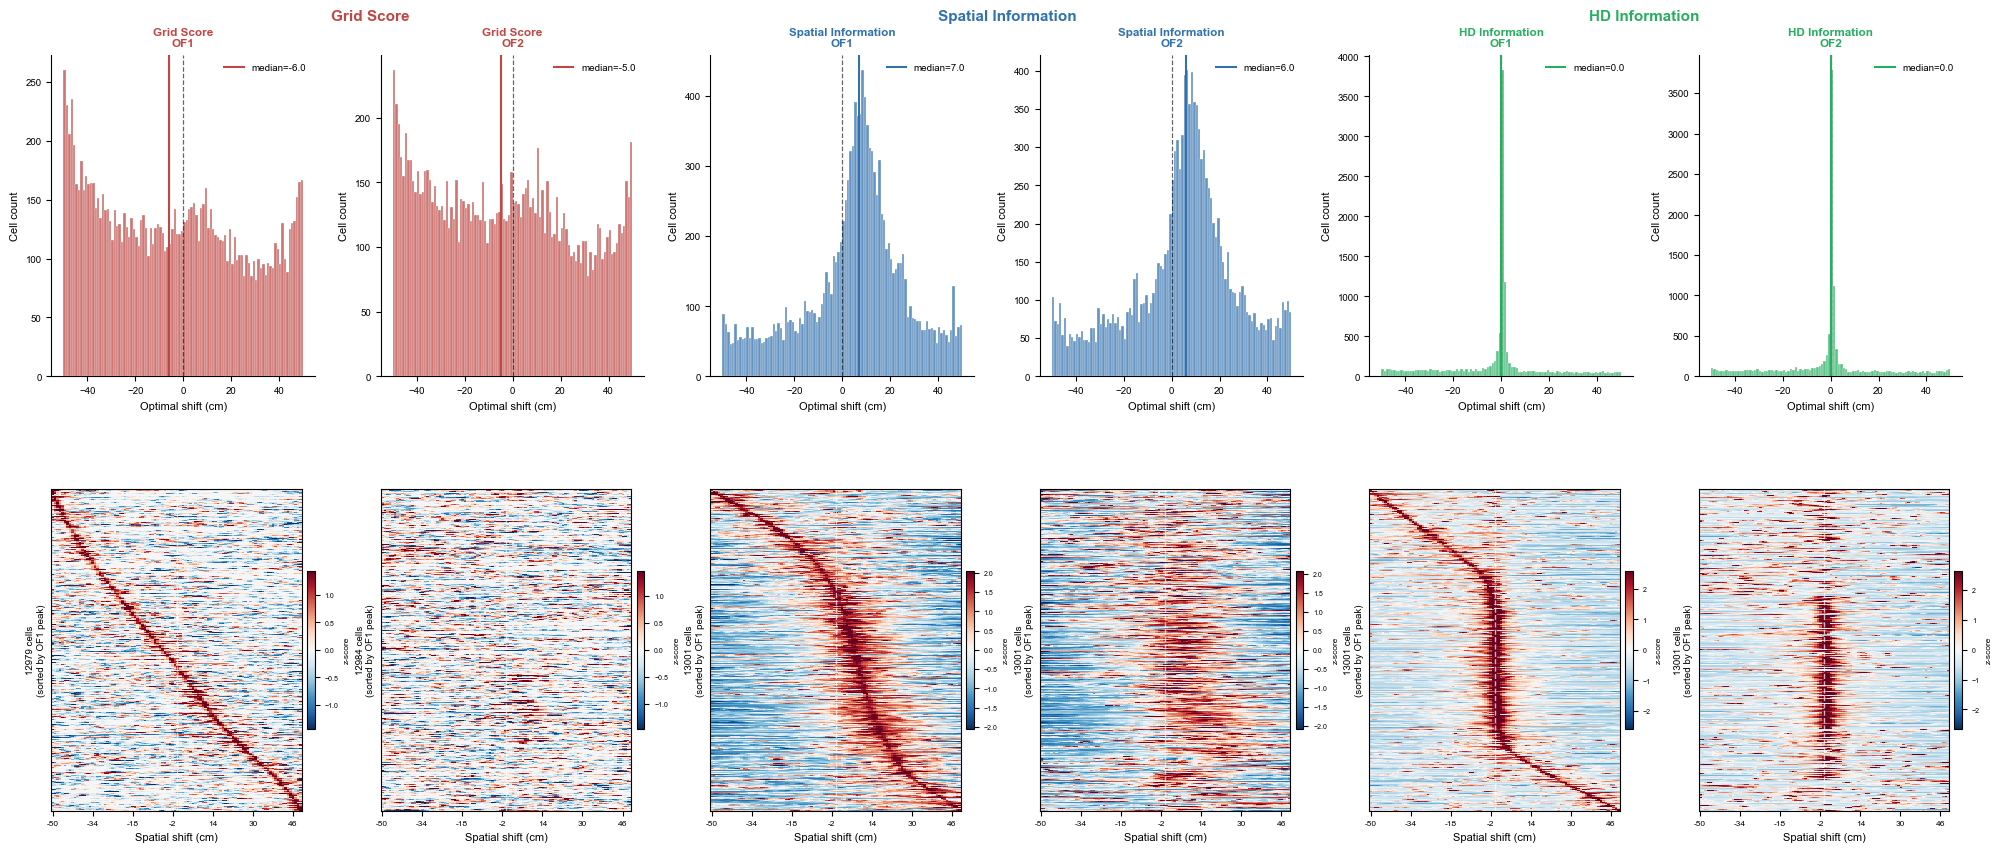

Saved.


In [4]:
metric_list = list(METRICS.keys())
n_metrics   = len(metric_list)
n_cols      = n_metrics * 2   # OF1 + OF2 for each metric

fig = plt.figure(figsize=(n_cols * 3.5, 9))
gs  = gridspec.GridSpec(2, n_cols, figure=fig,
                        hspace=0.35, wspace=0.25,
                        left=0.06, right=0.97, top=0.92, bottom=0.08)

for mi, metric in enumerate(metric_list):
    _, _, color = METRICS[metric]

    for si, sess in enumerate(SESSIONS):
        col = mi * 2 + si
        pv  = pivots[metric][sess]
        ol  = opt_lag[metric][sess]

        ax_hist = fig.add_subplot(gs[0, col])
        ax_hm   = fig.add_subplot(gs[1, col])

        if pv.empty:
            ax_hist.axis('off'); ax_hm.axis('off')
            continue

        lags = pv.columns.values.astype(float)

        # ── Row 0: histogram of optimal lag ──────────────────────────────────
        ax_hist.hist(ol.dropna(), bins=np.arange(lags.min(), lags.max()+2, 1),
                     color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
        ax_hist.axvline(0, color='k', lw=0.9, ls='--', alpha=0.6)
        ax_hist.axvline(ol.median(), color=color, lw=1.5, ls='-',
                        label=f'median={ol.median():.1f}')
        ax_hist.set_xlabel('Optimal shift (cm)', fontsize=8)
        ax_hist.set_ylabel('Cell count', fontsize=8)
        ax_hist.set_title(f'{metric}\n{sess}', fontsize=8.5,
                          fontweight='bold', color=color)
        ax_hist.legend(fontsize=7, frameon=False)
        ax_hist.spines[['top','right']].set_visible(False)
        ax_hist.tick_params(labelsize=7)

        # ── Row 1: heatmap — sort by OF1 optimal lag, keep for OF2 ───────────
        # Determine sort order from OF1
        ol_of1 = opt_lag[metric]['OF1']
        # Find cells present in this pivot
        cells_here = pv.index
        # Cells also present in OF1 opt_lag (for consistent sorting)
        shared = ol_of1.index.intersection(cells_here)
        sort_order = ol_of1.loc[shared].sort_values().index
        # Remaining cells (only in OF2 or not in OF1) go at the bottom
        only_here = cells_here.difference(shared)
        full_order = sort_order.tolist() + only_here.tolist()
        pv_sorted = pv.loc[[c for c in full_order if c in pv.index]]

        mat = pv_sorted.values.astype(float)
        # Z-score each row (cell) independently so curves are comparable
        row_mean = np.nanmean(mat, axis=1, keepdims=True)
        row_std  = np.nanstd(mat,  axis=1, keepdims=True)
        mat_z    = (mat - row_mean) / np.where(row_std > 0, row_std, 1)
        # Light Gaussian smoothing along the shift axis only
        mat_smooth = gaussian_filter(np.nan_to_num(mat_z), sigma=[0, 0.8])

        vmax = np.nanpercentile(np.abs(mat_smooth), 98)
        im   = ax_hm.imshow(mat_smooth, aspect='auto', cmap='RdBu_r',
                             vmin=-vmax, vmax=vmax, interpolation='nearest',
                             origin='upper')

        # Mark zero lag
        zero_col = np.searchsorted(lags, 0)
        ax_hm.axvline(zero_col - 0.5, color='white', lw=1.0, ls='--', alpha=0.7)

        # x-ticks: show a subset of lag values
        n_lag = len(lags)
        tick_step = max(1, n_lag // 6)
        tick_idx  = np.arange(0, n_lag, tick_step)
        ax_hm.set_xticks(tick_idx)
        ax_hm.set_xticklabels([f'{lags[t]:.0f}' for t in tick_idx], fontsize=6)
        ax_hm.set_xlabel('Spatial shift (cm)', fontsize=8)
        ax_hm.set_yticks([])
        ax_hm.set_ylabel(f'{len(pv_sorted)} cells\n(sorted by OF1 peak)', fontsize=7)

        cbar = plt.colorbar(im, ax=ax_hm, fraction=0.03, pad=0.02)
        cbar.set_label('z-score', fontsize=6)
        cbar.ax.tick_params(labelsize=5)

    # Column group label
    col0 = mi * 2
    fig.text((gs.left + (col0 / n_cols) * (gs.right - gs.left) +
              (gs.left + ((col0+2) / n_cols) * (gs.right - gs.left))) / 2,
             0.955, metric,
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             color=METRICS[metric][2])

fig.savefig(fig_path + 'shift_tuning_scores_all_cells.pdf',
            bbox_inches='tight', dpi=300)
plt.show()
print('Saved.')

## 4. Classify cells from parquet zero-shift scores vs null

Cell types are determined directly from the tuning score parquet files:
a cell passes if its score at `travel=0` exceeds the `null` value stored in the
parquet (the 95th-percentile threshold from shuffles) in at least one OF session.

- **GC**: `grid_score(0) > null_grid_score(0)`
- **NGS**: `spatial_information(0) > null_spatial_information(0)` AND not a GC
- **HD**: `hd_information(0) > null_hd_information(0)` (can overlap with GC/NGS)

In [5]:
NULL_COL = {
    'Grid Score':          'null_grid_score',
    'Spatial Information': 'null_spatial_information',
    'HD Information':      'null_hd_information',
}
SCORE_COL = {
    'Grid Score':          'grid_score',
    'Spatial Information': 'spatial_information',
    'HD Information':      'hd_information',
}

# ── Classification logic ─────────────────────────────────────────────────────
# At travel=0, for each cell:
#   - Get the actual score (grid_score / spatial_information / hd_information)
#   - Get the null array (~200 shuffled scores stored per cell per lag)
#   - Threshold = 95th percentile of that cell's null array
#   - Cell passes if actual_score > threshold
# Fallback: if null array is None (shuffles not run), use sig column at travel=0

zero_scores = {metric: {sess: pd.DataFrame() for sess in SESSIONS}
               for metric in METRICS}
uid_passes  = {}  # uid → {metric: {'OF1': bool, 'OF2': bool}}

for mouse, days in mouse_days.items():
    for day in days:
        for metric, (fname, _, color) in METRICS.items():
            score_col = SCORE_COL[metric]
            null_col  = NULL_COL[metric]
            for sess in SESSIONS:
                fpath = (f'{source_path}M{mouse}/D{day:02}/{sess}/'
                         f'tuning_scores/{fname}')
                if not os.path.exists(fpath):
                    continue
                try:
                    df = pd.read_parquet(fpath)
                    df0 = df[df['travel'] == 0].copy()
                    if df0.empty:
                        continue
                    df0['uid'] = df0['cluster_id'].astype(str).radd(
                        f'M{mouse}_D{day:02}_C')

                    if score_col not in df0.columns:
                        continue

                    rows = []
                    for _, r in df0.iterrows():
                        uid   = r['uid']
                        score = pd.to_numeric(r.get(score_col), errors='coerce')
                        if pd.isna(score):
                            continue

                        null_arr = r.get(null_col, None)
                        if null_arr is not None and hasattr(null_arr, '__len__'):
                            # Null is a full shuffle distribution — compute 95th pct
                            null_vals = np.array(null_arr, dtype=float)
                            null_vals = null_vals[~np.isnan(null_vals)]
                            if len(null_vals) == 0:
                                passes = bool(r.get('sig', False))
                                threshold = np.nan
                            else:
                                threshold = float(np.nanpercentile(null_vals, 95))
                                passes = float(score) > threshold
                        else:
                            # Null not stored — fall back to pre-computed sig at travel=0
                            passes = bool(r.get('sig', False))
                            threshold = np.nan

                        rows.append({'uid': uid, 'score': float(score),
                                     'threshold': threshold, 'passes': passes})
                        uid_passes.setdefault(uid, {}).setdefault(metric, {})[sess] = passes

                    if rows:
                        chunk = pd.DataFrame(rows)
                        zero_scores[metric][sess] = pd.concat(
                            [zero_scores[metric][sess], chunk], ignore_index=True)
                except Exception as e:
                    pass

# Passes if significant in at least one OF session
def passes_metric(uid, metric):
    d = uid_passes.get(uid, {}).get(metric, {})
    return len(d) > 0 and any(d.values())

all_uids = set(uid_passes.keys())
# GC: must pass BOTH grid score AND spatial information thresholds
# (mirrors classify_cells_both_sessions line 476)
uid_gc  = {u for u in all_uids
           if passes_metric(u, 'Grid Score')
           and passes_metric(u, 'Spatial Information')}
# NGS: passes spatial information but NOT grid score
uid_ngs = {u for u in all_uids
           if passes_metric(u, 'Spatial Information') and u not in uid_gc}
uid_hd  = {u for u in all_uids if passes_metric(u, 'HD Information')}

if not uid_gc and not uid_ngs and not uid_hd:
    print('WARNING: no cells classified.')

SUBSETS = {
    'Grid cells (GC)':       (uid_gc,  '#c04744'),
    'NGS cells':             (uid_ngs, '#3171ae'),
    'Head direction cells':  (uid_hd,  '#27ae60'),
}

print('Classification: score(travel=0) > 95th pct of per-cell null distribution')
print('  (fallback to sig column at travel=0 when null array not stored)')
print(f'  GC:  {len(uid_gc):5d}')
print(f'  NGS: {len(uid_ngs):5d}  (spatial but not GC)')
print(f'  HD:  {len(uid_hd):5d}')
print(f'  Conjunctive (GC+HD): {len(uid_gc & uid_hd)}')


Classification: score(travel=0) > 95th pct of per-cell null distribution
  (fallback to sig column at travel=0 when null array not stored)
  GC:    381
  NGS:  6287  (spatial but not GC)
  HD:   8363
  Conjunctive (GC+HD): 259


## 5. Zero-travel score vs null threshold — by cell subset

Distribution of the unshifted (travel=0) score for each subset,
overlaid with the per-cell null threshold.
The dashed line shows the 95th percentile of null values across cells in the subset.

In [6]:
# zero_scores and uid sets are already computed in the cell above
print('Ready to plot.')
for metric in METRICS:
    for sess in SESSIONS:
        n = len(zero_scores[metric][sess])
        print(f'  {metric:22s} {sess}: {n} rows')


Ready to plot.
  Grid Score             OF1: 6436 rows
  Grid Score             OF2: 6834 rows
  Spatial Information    OF1: 13001 rows
  Spatial Information    OF2: 13001 rows
  HD Information         OF1: 13001 rows
  HD Information         OF2: 13001 rows


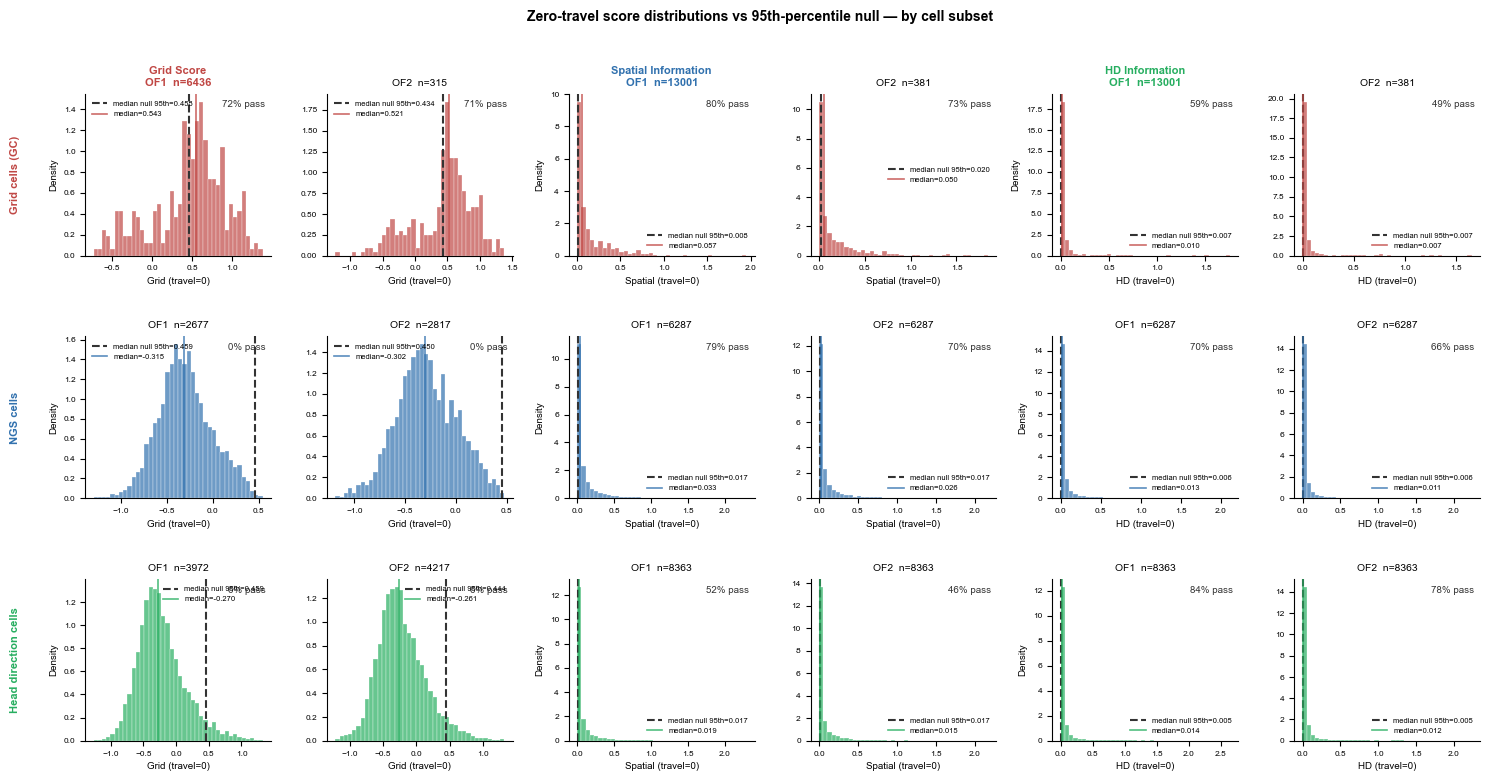

Saved zero-travel plot.


In [7]:
n_subsets = len(SUBSETS)
n_metrics = len(METRICS)
metric_list = list(METRICS.keys())
subset_list = list(SUBSETS.keys())

fig, axes = plt.subplots(
    n_subsets, n_metrics * 2,
    figsize=(n_metrics * 2 * 3.0, n_subsets * 2.8),
    gridspec_kw={'hspace': 0.50, 'wspace': 0.30}
)

for si, (subset_label, (uid_set, sub_color)) in enumerate(SUBSETS.items()):
    for mi, metric in enumerate(metric_list):
        _, _, met_color = METRICS[metric]
        for sei, sess in enumerate(SESSIONS):
            ax  = axes[si, mi * 2 + sei]
            df0 = zero_scores[metric][sess]
            if df0.empty:
                ax.axis('off'); continue

            sub_df = df0[df0['uid'].isin(uid_set)].dropna(subset=['score'])
            if sub_df.empty:
                ax.axis('off'); continue

            scores = sub_df['score'].values
            # threshold = per-cell 95th pct of null array (or sig fallback)
            thresholds = sub_df['threshold'].dropna().values

            # Histogram of scores
            ax.hist(scores, bins=40, color=sub_color, alpha=0.70,
                    edgecolor='white', linewidth=0.3, density=True)

            # Median threshold across cells as reference line
            if len(thresholds) > 0:
                med_thresh = float(np.nanmedian(thresholds))
                ax.axvline(med_thresh, color='#333333', lw=1.5, ls='--',
                           label=f'median null 95th={med_thresh:.3f}')
                pct_above = 100 * np.mean(sub_df['passes'].values)
                ax.text(0.97, 0.96, f'{pct_above:.0f}% pass',
                        transform=ax.transAxes, ha='right', va='top',
                        fontsize=7, color='#333333')

            ax.axvline(np.nanmedian(scores), color=sub_color, lw=1.2,
                       ls='-', alpha=0.8, label=f'median={np.nanmedian(scores):.3f}')

            ax.set_xlabel(f'{metric.split()[0]} (travel=0)', fontsize=7)
            ax.set_ylabel('Density' if sei == 0 else '', fontsize=7)
            ax.set_title(f'{sess}  n={len(sub_df)}', fontsize=7.5)
            if mi == 0 and sei == 0:
                ax.text(-0.35, 0.5, subset_label, transform=ax.transAxes,
                        fontsize=8, fontweight='bold', color=sub_color,
                        va='center', ha='right', rotation=90)
            ax.legend(fontsize=5.5, frameon=False)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=6)

    # Column headers
for mi, metric in enumerate(metric_list):
    axes[0, mi * 2].set_title(f'{metric}\nOF1  n={len(zero_scores[metric]["OF1"])}',
                               fontsize=8, fontweight='bold',
                               color=METRICS[metric][2])

fig.suptitle('Zero-travel score distributions vs 95th-percentile null — by cell subset',
             fontsize=10, fontweight='bold')
fig.savefig(fig_path + 'shift_zero_travel_subsets.pdf', bbox_inches='tight', dpi=200)
plt.show()
print('Saved zero-travel plot.')

## 6. Shift heatmaps by cell subset

Same 6-column × 2-row layout as the full figure,
but restricted to each cell subset separately.

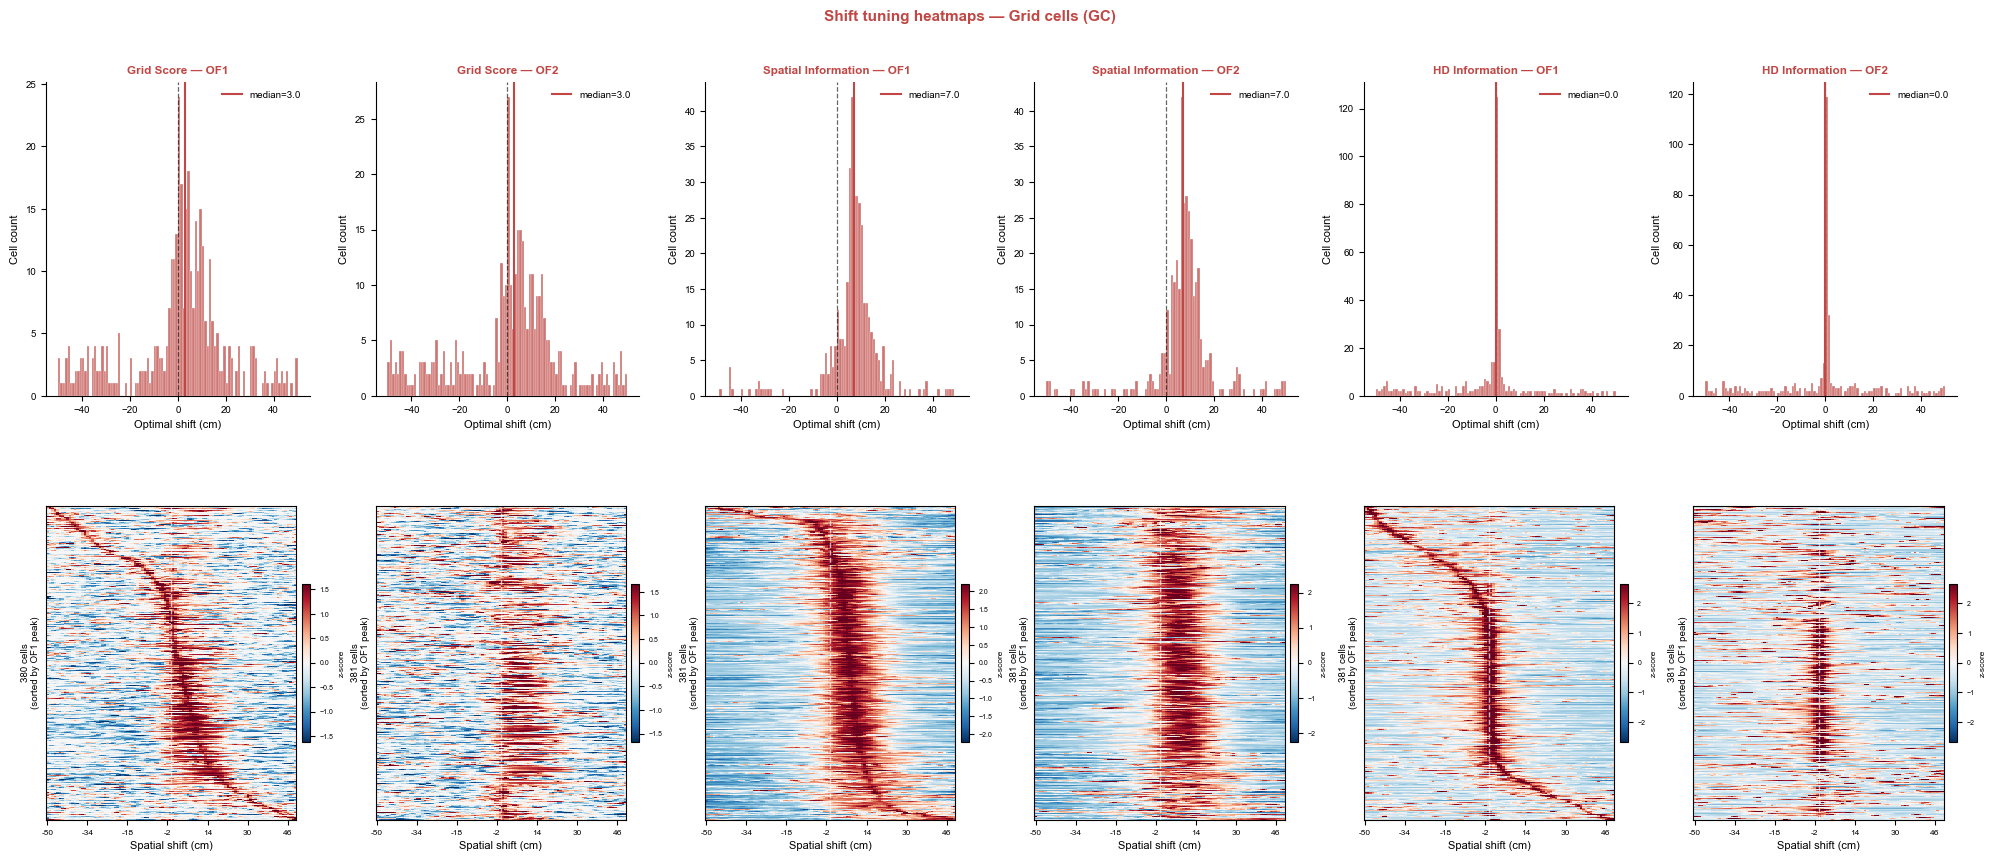

Saved: Grid cells (GC)


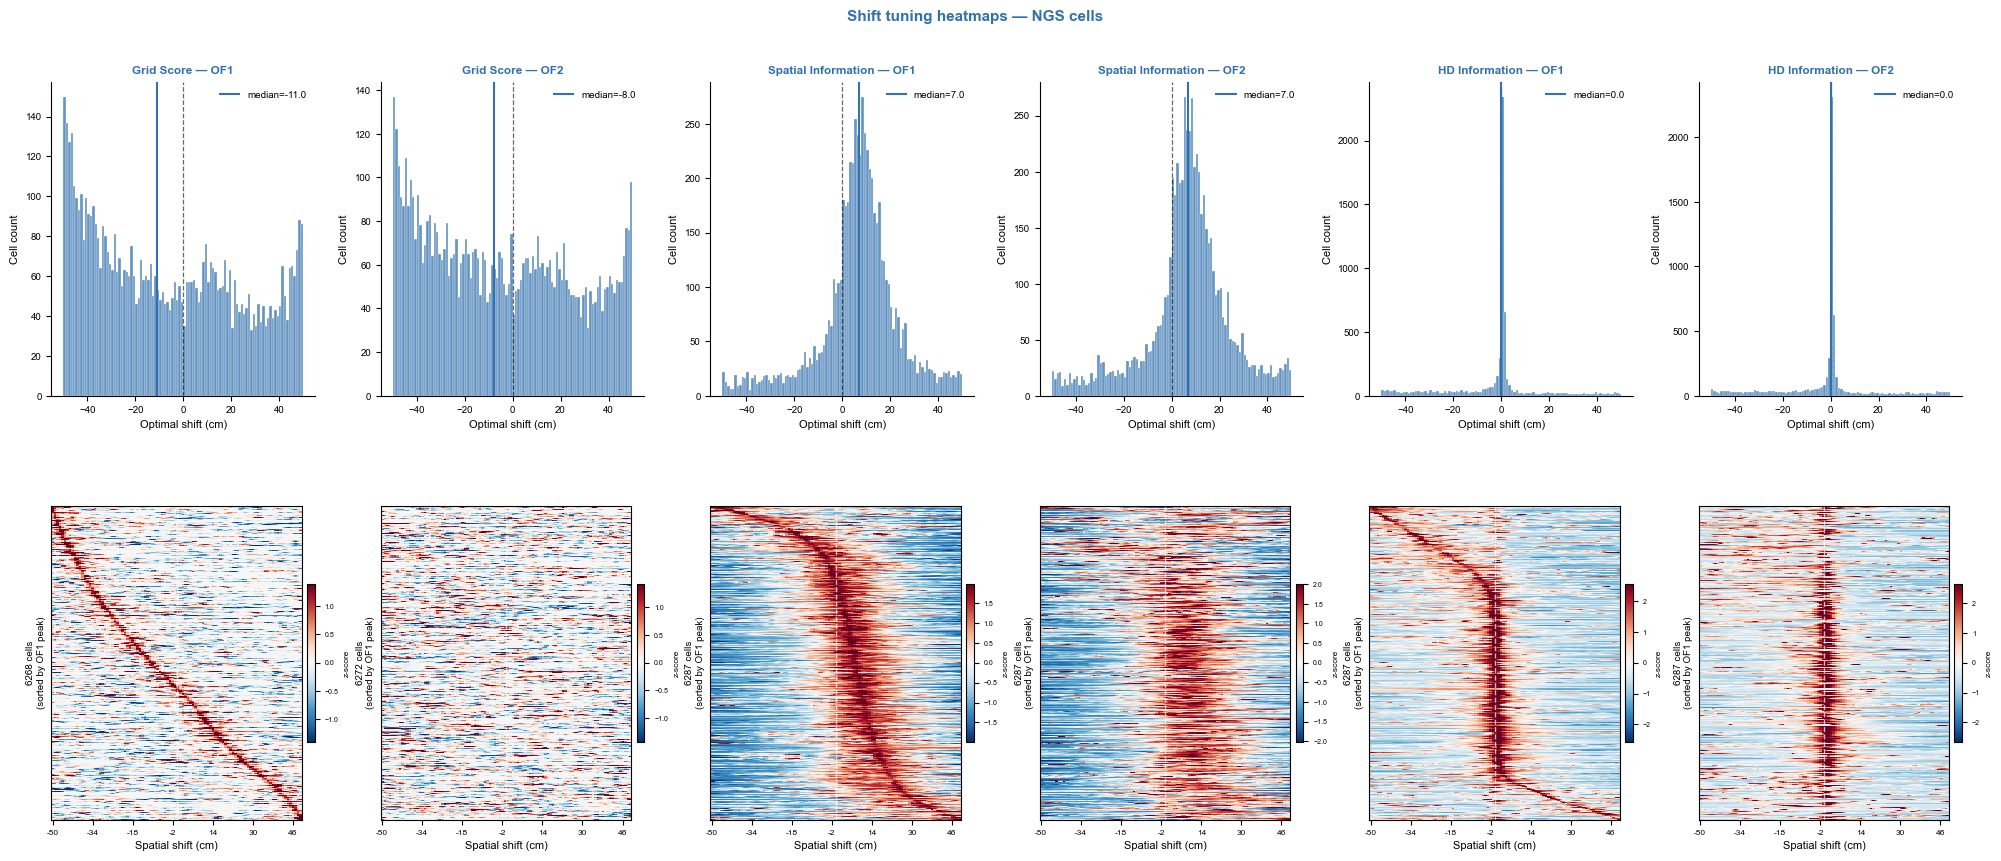

Saved: NGS cells


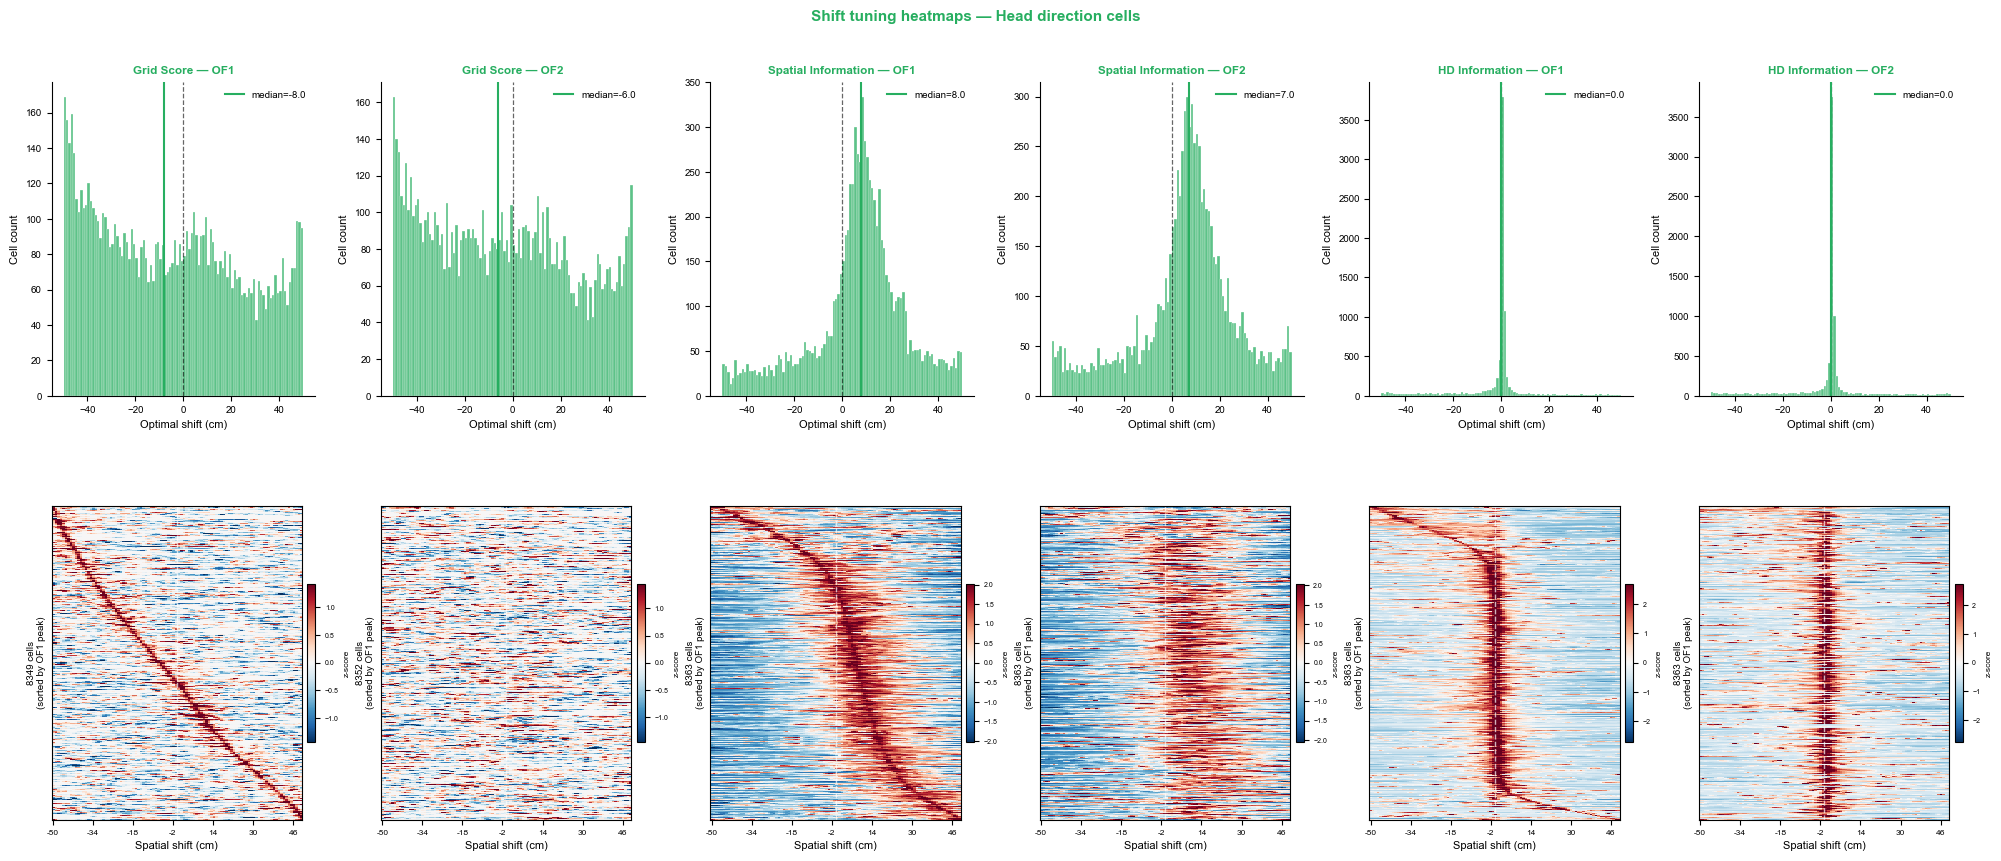

Saved: Head direction cells


In [8]:
for subset_label, (uid_set, sub_color) in SUBSETS.items():
    n_metrics  = len(metric_list)
    n_cols_fig = n_metrics * 2

    fig2 = plt.figure(figsize=(n_cols_fig * 3.5, 9))
    gs2  = gridspec.GridSpec(2, n_cols_fig, figure=fig2,
                             hspace=0.35, wspace=0.25,
                             left=0.06, right=0.97, top=0.90, bottom=0.08)

    for mi, metric in enumerate(metric_list):
        _, _, met_color = METRICS[metric]

        # Build subset pivots and optimal lags
        sub_pivots   = {}
        sub_opt_lags = {}
        for sess in SESSIONS:
            pv = pivots[metric][sess]
            if pv.empty:
                sub_pivots[sess]   = pd.DataFrame()
                sub_opt_lags[sess] = pd.Series(dtype=float)
                continue
            sub_pv = pv.loc[pv.index.isin(uid_set)]
            sub_pivots[sess]   = sub_pv
            sub_opt_lags[sess] = sub_pv.idxmax(axis=1) if not sub_pv.empty else pd.Series(dtype=float)

        for si, sess in enumerate(SESSIONS):
            col     = mi * 2 + si
            pv      = sub_pivots[sess]
            ol      = sub_opt_lags[sess]
            ax_hist = fig2.add_subplot(gs2[0, col])
            ax_hm   = fig2.add_subplot(gs2[1, col])

            if pv.empty:
                ax_hist.axis('off'); ax_hm.axis('off')
                continue

            lags = pv.columns.values.astype(float)

            # ── Row 0: histogram of optimal lag ──────────────────────────────
            ax_hist.hist(ol.dropna(), bins=np.arange(lags.min(), lags.max()+2, 1),
                         color=sub_color, alpha=0.75, edgecolor='white', linewidth=0.3)
            ax_hist.axvline(0, color='k', lw=0.9, ls='--', alpha=0.6)
            ax_hist.axvline(ol.median(), color=sub_color, lw=1.5, ls='-',
                            label=f'median={ol.median():.1f}')
            ax_hist.set_xlabel('Optimal shift (cm)', fontsize=8)
            ax_hist.set_ylabel('Cell count', fontsize=8)
            ax_hist.set_title(f'{metric} — {sess}', fontsize=8.5,
                              fontweight='bold', color=sub_color)
            ax_hist.legend(fontsize=7, frameon=False)
            ax_hist.spines[['top','right']].set_visible(False)
            ax_hist.tick_params(labelsize=7)

            # ── Row 1: z-scored heatmap sorted by OF1 optimal lag ────────────
            ol_of1    = sub_opt_lags['OF1']
            shared    = ol_of1.index.intersection(pv.index)
            sort_ord  = ol_of1.loc[shared].sort_values().index
            only_here = pv.index.difference(shared)
            full_ord  = sort_ord.tolist() + only_here.tolist()
            pv_sorted = pv.loc[[c for c in full_ord if c in pv.index]]

            mat      = pv_sorted.values.astype(float)
            row_mean = np.nanmean(mat, axis=1, keepdims=True)
            row_std  = np.nanstd(mat,  axis=1, keepdims=True)
            mat_z    = (mat - row_mean) / np.where(row_std > 0, row_std, 1)
            mat_s    = gaussian_filter(np.nan_to_num(mat_z), sigma=[0, 0.8])

            vmax = np.nanpercentile(np.abs(mat_s), 98)
            im   = ax_hm.imshow(mat_s, aspect='auto', cmap='RdBu_r',
                                vmin=-vmax, vmax=vmax, interpolation='nearest',
                                origin='upper')

            zero_col = np.searchsorted(lags, 0)
            ax_hm.axvline(zero_col - 0.5, color='white', lw=1.0, ls='--', alpha=0.7)

            n_lag     = len(lags)
            tick_step = max(1, n_lag // 6)
            tick_idx  = np.arange(0, n_lag, tick_step)
            ax_hm.set_xticks(tick_idx)
            ax_hm.set_xticklabels([f'{lags[t]:.0f}' for t in tick_idx], fontsize=6)
            ax_hm.set_xlabel('Spatial shift (cm)', fontsize=8)
            ax_hm.set_yticks([])
            ax_hm.set_ylabel(f'{len(pv_sorted)} cells\n(sorted by OF1 peak)', fontsize=7)

            cbar = plt.colorbar(im, ax=ax_hm, fraction=0.03, pad=0.02)
            cbar.set_label('z-score', fontsize=6)
            cbar.ax.tick_params(labelsize=5)

    fig2.suptitle(f'Shift tuning heatmaps — {subset_label}',
                  fontsize=11, fontweight='bold', color=sub_color)
    safe_label = subset_label.replace(' ', '_').replace('(', '').replace(')', '')
    fig2.savefig(fig_path + f'shift_heatmap_{safe_label}.pdf',
                 bbox_inches='tight', dpi=200)
    plt.show()
    print(f'Saved: {subset_label}')